In [2]:
from python_utilities.db_connection import DbConnection
import pandas as pd

In [3]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-02-24 15:45:19] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [4]:
query = """
SELECT *
FROM llm_attachments_predictions
WHERE created_at >= '2026-01-01'
"""

data = analytics_db.sql_to_df(query)

In [5]:
data.head()

,id,created_at,model_name,type,subtype,value,attachment_id
0,2637339,2026-01-01 01:27:37,payment_proof,payment_proof,is_payment_proof,'False',24552630528924-1
1,2637340,2026-01-01 01:27:37,payment_proof,payment_proof,payment_proof_type,'none',24552630528924-1
2,2637341,2026-01-01 01:27:37,aftercourt_classification,aftercourt_classification,is_aftercourt,'False',24552630528924-1
3,2637342,2026-01-01 01:27:37,debt_counseling_attachment,debt_counseling_attachment,attachment_type,'other',24552630528924-1
4,2637343,2026-01-01 01:27:37,debt_counseling_attachment,debt_counseling_attachment,counselling_slug,'P.P.',24552630528924-1


In [6]:
data['model_name'].unique()

array(['payment_proof', 'aftercourt_classification',
       'debt_counseling_attachment', 'multi_attachment',
       'aftercourt_classification_ladung',
       'aftercourt_classification_pfub', 'invoice'], dtype=object)

In [7]:
data['type'].unique()

array(['payment_proof', 'aftercourt_classification',
       'debt_counseling_attachment', 'multi_attachment',
       'aftercourt_classification_ladung',
       'aftercourt_classification_pfub', 'invoice'], dtype=object)

In [8]:
data['subtype'].unique()

array(['is_payment_proof', 'payment_proof_type', 'is_aftercourt',
       'attachment_type', 'counselling_slug', 'counsellor_address',
       'counsellor_agency_name', 'counsellor_email', 'debtor_firstname',
       'debtor_lastname', 'recipient', 'recipient_iban', 'payment_date',
       'payment_amount', 'sender_iban', 'settlement_amount_offer_to_us',
       'aftercourt_type', 'slug', 'debtor_name', 'judicial_summon_date',
       'casefile_number', 'counsellor_firstname', 'counsellor_lastname',
       'installment_plan_start_date', 'number_of_installments',
       'monthly_installment_amount_offer_to_us', 'class_pred',
       'class_prob', 'is_invoice', 'invoice_date', 'invoice_number'],
      dtype=object)

In [9]:
ladung_preds = data[data['type'] == 'aftercourt_classification_ladung']
ladung_preds

,id,created_at,model_name,type,subtype,value,attachment_id
411059,3048398,2026-01-19 10:14:43,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va',24921336934428-3
411060,3048399,2026-01-19 10:14:43,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False',24921336934428-3
411061,3048400,2026-01-19 10:14:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.0',24921336934428-3
411073,3048412,2026-01-19 10:14:44,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va',24921349659932-1
411074,3048413,2026-01-19 10:14:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False',24921349659932-1
...,...,...,...,...,...,...,...
2272815,4910154,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'True',53789432
2272816,4910155,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'1.0',53789432
2272817,4910156,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,slug,'189406589730',53789432
2272818,4910157,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Amy Elise Gutekunst',53789432


In [10]:
ladung_probs = ladung_preds[(ladung_preds['subtype'] == 'class_prob')]
high_prob_attachments = ladung_probs[(ladung_probs['value'].apply(lambda x: float(eval(x))) > 0.5)]

In [11]:
high_prob_attachments

,id,created_at,model_name,type,subtype,value,attachment_id
451202,3088541,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.99',24951795690908-1
451221,3088560,2026-01-20 16:44:46,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.96',24951795690908-2
455851,3093190,2026-01-20 16:48:56,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.78',50219868
455868,3093207,2026-01-20 16:48:57,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.52',50219884
455876,3093215,2026-01-20 16:48:58,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'1.0',50219888
...,...,...,...,...,...,...,...
2272723,4910062,2026-02-24 11:39:40,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'1.0',53789346
2272770,4910109,2026-02-24 11:39:42,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.78',53789389
2272776,4910115,2026-02-24 11:39:43,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'1.0',53789395
2272785,4910124,2026-02-24 11:39:43,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.96',53789402


In [12]:
unique_attachment_id = high_prob_attachments['attachment_id'].unique()

In [13]:
check = ladung_preds[ladung_preds['attachment_id'].isin(unique_attachment_id)]
check

,id,created_at,model_name,type,subtype,value,attachment_id
451200,3088539,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va',24951795690908-1
451201,3088540,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'True',24951795690908-1
451202,3088541,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.99',24951795690908-1
451203,3088542,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,slug,'177560684736',24951795690908-1
451204,3088543,2026-01-20 16:44:45,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Anja Valdeig',24951795690908-1
...,...,...,...,...,...,...,...
2272815,4910154,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'True',53789432
2272816,4910155,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'1.0',53789432
2272817,4910156,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,slug,'189406589730',53789432
2272818,4910157,2026-02-24 11:39:44,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Amy Elise Gutekunst',53789432


In [14]:
for attachment_id in unique_attachment_id:
    temp = ladung_preds[ladung_preds['attachment_id'] == attachment_id]
    class_pred = temp[temp['subtype'] == 'class_pred']
    class_prob = temp[temp['subtype'] == 'class_prob']
    debtor_name = temp[temp['subtype'] == 'debtor_name']
    slug = temp[temp['subtype'] == 'slug']
    judicial_summon_date = temp[temp['subtype'] == 'judicial_summon_date']  
    print(f"Attachment ID: {attachment_id}")
    print(f"Class Prediction: {class_pred['value'].values[0] if not class_pred.empty else 'N/A'}")
    print(f"Class Probability: {class_prob['value'].values[0] if not class_prob.empty else 'N/A'}")
    print(f"Debtor Name: {debtor_name['value'].values[0] if not debtor_name.empty else 'N/A'}")
    print(f"Slug: {slug['value'].values[0] if not slug.empty else 'N/A'}")
    print(f"Judicial Summon Date: {judicial_summon_date['value'].values[0] if not judicial_summon_date.empty else 'N/A'}")
    print("-" * 50)
    break

Attachment ID: 24951795690908-1
Class Prediction: 'True'
Class Probability: '0.99'
Debtor Name: 'Anja Valdeig'
Slug: '177560684736'
Judicial Summon Date: '26-01-2026'
--------------------------------------------------


In [15]:
subtypes = ['class_pred', 'class_prob', 'debtor_name', 'slug', 'judicial_summon_date']

flat_df = (
    ladung_preds[
        ladung_preds['attachment_id'].isin(unique_attachment_id) &
        ladung_preds['subtype'].isin(subtypes)
    ]
    .pivot_table(index='attachment_id', columns='subtype', values='value', aggfunc='first')
    .reset_index()
    [['attachment_id'] + subtypes]
)
flat_df

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date
0,20203015109660-1,'False','0.81',NaN,NaN,NaN
1,20204420411036-1,'True','1.0','Katarina Tirpakova','161045853256','19-08-2025'
2,20220891208732-1,'True','1.0','Wiethaler Renate','166307808443','30-06-2025'
3,20232736504220-1,'False','0.91',NaN,NaN,NaN
4,20871070436124-1,'True','1.0','Umejr Emin Mehmedovic','154369780700','20-08-2025'
...,...,...,...,...,...,...
5167,53789346,'True','1.0','Madeleine Falk','165268069169','16-03-2026'
5168,53789389,'False','0.78',NaN,NaN,NaN
5169,53789395,'True','1.0','Yordanka Zapryanova Dobreva','166884509372','13-03-2026'
5170,53789402,'True','0.96','Baris Yilmaz','178913231126','16-03-2026'


In [16]:
flat_df.attachment_id.is_unique

True

In [17]:
flat_df.describe(include='all')

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date
count,5172,5172,5172,2884,2866,2866
unique,5172,2,50,2711,2787,200
top,20203015109660-1,'True','1.0','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'173988604232','10-03-2026'
freq,1,2903,1812,7,4,140


check below documents

RESULTS: All of them are protokol documents, Add it to the database and retrain the model

In [18]:
check = flat_df[flat_df['debtor_name'] == "'Diese Kostenrechnung Kann Schriftlich Oder Zu Protokoll Der Geschäftsstelle Erinnerung Bei'"]
check

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date
625,50220741,'True','0.7','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'186841816348','21-01-2026'
732,50223768,'True','0.93','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'186411890145','08-10-2025'
748,50225565,'True','0.84','Diese Kostenrechnung Kann Schriftlich Oder Zu...,NaN,'21-03-2024'
799,50226657,'True','0.92','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'176051266326','28-07-2025'
894,50393046,'True','0.9','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'185899021736','19-01-2026'
910,50396435,'True','0.92','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'172721773015','07-08-2025'
975,50424732,'True','0.67','Diese Kostenrechnung Kann Schriftlich Oder Zu...,'173988604232','20-01-2026'


In [19]:
from utils import get_data_by_attachment_id
import boto3
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')
# Create session with specific profile
session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')
get_data_by_attachment_id("50396435", analytics_db, s3, pdf_download=True, pdf_download_dir="/Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs")

INFO [2026-02-24 15:46:14] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file
INFO [2026-02-24 15:46:14] - Found credentials in shared credentials file: ~/.aws/credentials



📎 ATTACHMENT SUMMARY
Attachment ID:   50396435
File Name:       50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-01-21/egvp_id_294724/50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf
│
│ 📝 Textract Output:
│    s3://pair-data-engineering-new/ocr_prepared_output/6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8cc0b79d1b8cd63bdb18.json
│
│ 📊 Text Length:  4432 characters
│
│ 📥 PDF Downloaded: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/50396435.pdf
│
│ 🤖 PREDICTIONS:
│    Class:      ladung
│    Prob Ladung: '0.92'
│    Prob Pfub:   '0.0'
└──────────────────────────────────────────────────────────────────────────────────────────────────



,attachment_id,document_s3_key,document_s3_bucket,file_name,model_name,type,subtype,value,textract_job_id,textract_status,textract_s3_link,text
0,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
1,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'True',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
2,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.92',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
3,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,slug,'172721773015',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
4,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Diese Kostenrechnung Kann Schriftlich Oder Zu...,6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
5,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_ladung,aftercourt_classification_ladung,judicial_summon_date,'07-08-2025',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
6,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
7,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...
8,50396435,ocr_source_files/2026-01-21/egvp_id_294724/503...,pair-data-engineering-new,50396435_Protokoll_GKB-EV21_21_01_2026__Gl_.pdf,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.0',6034f48cfeb68e280125edda97ecec7d02ce36e0c0db8c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,STEFAN HOFFMANN\nDie nachstehend gewählten For...


In [20]:
flat_df['class_pred_parsed'] = flat_df['class_pred'].apply(lambda x: True if x == "'True'" else False)
flat_df['class_prob_parsed'] = flat_df['class_prob'].apply(lambda x: float(eval(x)) if x is not None else None)
flat_df[['attachment_id', 'class_pred_parsed', 'class_prob_parsed']]

subtype,attachment_id,class_pred_parsed,class_prob_parsed
0,20203015109660-1,False,0.81
1,20204420411036-1,True,1.00
2,20220891208732-1,True,1.00
3,20232736504220-1,False,0.91
4,20871070436124-1,True,1.00
...,...,...,...
5167,53789346,True,1.00
5168,53789389,False,0.78
5169,53789395,True,1.00
5170,53789402,True,0.96


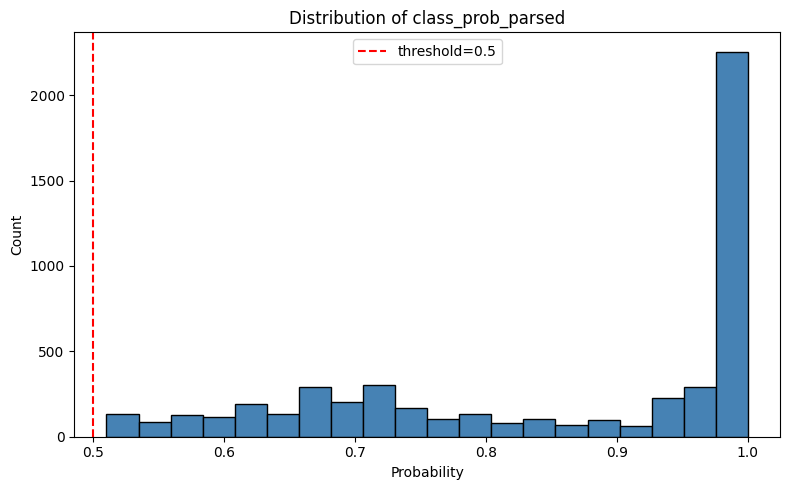

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(flat_df['class_prob_parsed'].dropna(), bins=20, edgecolor='black', color='steelblue')
ax.set_title('Distribution of class_prob_parsed')
ax.set_xlabel('Probability')
ax.set_ylabel('Count')
ax.axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
prob_ranges = {
    '0.5-0.6': len(flat_df[(flat_df['class_prob_parsed'] >= 0.5) & (flat_df['class_prob_parsed'] < 0.6)]),
    '0.6-0.7': len(flat_df[(flat_df['class_prob_parsed'] >= 0.6) & (flat_df['class_prob_parsed'] < 0.7)]),
    '0.7-0.8': len(flat_df[(flat_df['class_prob_parsed'] >= 0.7) & (flat_df['class_prob_parsed'] < 0.8)]),
    '0.8-0.9': len(flat_df[(flat_df['class_prob_parsed'] >= 0.8) & (flat_df['class_prob_parsed'] < 0.9)]),
    '0.9-1': len(flat_df[(flat_df['class_prob_parsed'] >= 0.9) & (flat_df['class_prob_parsed'] <= 1)])
}
for range_label, count in prob_ranges.items():
    print(f"Range {range_label}: {count} attachments")

Range 0.5-0.6: 394 attachments
Range 0.6-0.7: 784 attachments
Range 0.7-0.8: 776 attachments
Range 0.8-0.9: 350 attachments
Range 0.9-1: 2868 attachments


In [23]:
# for each range, calculate number of slug presence and absence. start from 0.5
ranges = [
    ('0.5-0.6', 0.5, 0.6),
    ('0.6-0.7', 0.6, 0.7),
    ('0.7-0.8', 0.7, 0.8),
    ('0.8-0.9', 0.8, 0.9),
    ('0.9-1.0', 0.9, 1.0),
]

for label, low, high in ranges:
    mask = (flat_df['class_prob_parsed'] >= low) & (flat_df['class_prob_parsed'] < high if high < 1.0 else flat_df['class_prob_parsed'] <= high)
    total = mask.sum()
    with_slug = (mask & flat_df['slug'].notna()).sum()
    pct = (with_slug / total * 100) if total > 0 else 0
    print(f"Range {label}: {with_slug}/{total} attachments with slug presence ({pct:.1f}%)")

Range 0.5-0.6: 28/394 attachments with slug presence (7.1%)
Range 0.6-0.7: 84/784 attachments with slug presence (10.7%)
Range 0.7-0.8: 73/776 attachments with slug presence (9.4%)
Range 0.8-0.9: 25/350 attachments with slug presence (7.1%)
Range 0.9-1.0: 2656/2868 attachments with slug presence (92.6%)


In [24]:
ranges = [
    ('0.5-0.6', 0.5, 0.6),
    ('0.6-0.7', 0.6, 0.7),
    ('0.7-0.8', 0.7, 0.8),
    ('0.8-0.9', 0.8, 0.9),
    ('0.9-1.0', 0.9, 1.0),
]

for col in ['debtor_name', 'judicial_summon_date']:
    print(f"\n--- {col} presence by probability range ---")
    for label, low, high in ranges:
        mask = (flat_df['class_prob_parsed'] >= low) & (flat_df['class_prob_parsed'] < high if high < 1.0 else flat_df['class_prob_parsed'] <= high)
        total = mask.sum()
        with_val = (mask & flat_df[col].notna()).sum()
        pct = (with_val / total * 100) if total > 0 else 0
        print(f"  Range {label}: {with_val}/{total} attachments with {col} presence ({pct:.1f}%)")


--- debtor_name presence by probability range ---
  Range 0.5-0.6: 28/394 attachments with debtor_name presence (7.1%)
  Range 0.6-0.7: 86/784 attachments with debtor_name presence (11.0%)
  Range 0.7-0.8: 73/776 attachments with debtor_name presence (9.4%)
  Range 0.8-0.9: 24/350 attachments with debtor_name presence (6.9%)
  Range 0.9-1.0: 2673/2868 attachments with debtor_name presence (93.2%)

--- judicial_summon_date presence by probability range ---
  Range 0.5-0.6: 27/394 attachments with judicial_summon_date presence (6.9%)
  Range 0.6-0.7: 82/784 attachments with judicial_summon_date presence (10.5%)
  Range 0.7-0.8: 70/776 attachments with judicial_summon_date presence (9.0%)
  Range 0.8-0.9: 29/350 attachments with judicial_summon_date presence (8.3%)
  Range 0.9-1.0: 2658/2868 attachments with judicial_summon_date presence (92.7%)


In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ranges = [
    ('0.5-0.6', 0.5, 0.6),
    ('0.6-0.7', 0.6, 0.7),
    ('0.7-0.8', 0.7, 0.8),
    ('0.8-0.9', 0.8, 0.9),
    ('0.9-1.0', 0.9, 1.0),
]
fields = ['slug', 'debtor_name', 'judicial_summon_date']

# Build summary data
summary = {field: {'range': [], 'total': [], 'present': [], 'pct': []} for field in fields}

for label, low, high in ranges:
    mask = (flat_df['class_prob_parsed'] >= low) & (
        flat_df['class_prob_parsed'] < high if high < 1.0 else flat_df['class_prob_parsed'] <= high
    )
    total = int(mask.sum())
    for field in fields:
        present = int((mask & flat_df[field].notna()).sum())
        pct = (present / total * 100) if total > 0 else 0
        summary[field]['range'].append(label)
        summary[field]['total'].append(total)
        summary[field]['present'].append(present)
        summary[field]['pct'].append(round(pct, 1))

# --- Plot 1: Extraction % per field per range (grouped bar) ---
fig1 = go.Figure()
colors = {'slug': '#636EFA', 'debtor_name': '#EF553B', 'judicial_summon_date': '#00CC96'}

for field in fields:
    fig1.add_trace(go.Bar(
        name=field,
        x=summary[field]['range'],
        y=summary[field]['pct'],
        text=[f"{p}%" for p in summary[field]['pct']],
        textposition='outside',
        marker_color=colors[field],
        customdata=list(zip(summary[field]['present'], summary[field]['total'])),
        hovertemplate='%{x}<br>%{customdata[0]}/%{customdata[1]} (%{y}%)<extra>' + field + '</extra>'
    ))

fig1.update_layout(
    title='Extraction Rate (%) by Probability Range',
    xaxis_title='Probability Range',
    yaxis_title='Extraction Rate (%)',
    yaxis=dict(range=[0, 115]),
    barmode='group',
    legend_title='Field',
    height=500,
    template='plotly_white'
)
fig1.show()

# --- Plot 2: Absolute counts stacked (present vs missing) per field ---
fig2 = make_subplots(rows=1, cols=3, subplot_titles=fields, shared_yaxes=True)

for i, field in enumerate(fields, 1):
    missing = [t - p for t, p in zip(summary[field]['total'], summary[field]['present'])]
    fig2.add_trace(go.Bar(name='Present', x=summary[field]['range'], y=summary[field]['present'],
                          marker_color=colors[field], showlegend=(i == 1),
                          hovertemplate='%{x}: %{y} present<extra></extra>'), row=1, col=i)
    fig2.add_trace(go.Bar(name='Missing', x=summary[field]['range'], y=missing,
                          marker_color='lightgrey', showlegend=(i == 1),
                          hovertemplate='%{x}: %{y} missing<extra></extra>'), row=1, col=i)

fig2.update_layout(
    title='Present vs Missing Counts by Probability Range',
    barmode='stack',
    height=500,
    template='plotly_white',
    legend_title='Status'
)
fig2.show()

In [26]:
# all attachments

In [27]:
flat_df

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
0,20203015109660-1,'False','0.81',NaN,NaN,NaN,False,0.81
1,20204420411036-1,'True','1.0','Katarina Tirpakova','161045853256','19-08-2025',True,1.00
2,20220891208732-1,'True','1.0','Wiethaler Renate','166307808443','30-06-2025',True,1.00
3,20232736504220-1,'False','0.91',NaN,NaN,NaN,False,0.91
4,20871070436124-1,'True','1.0','Umejr Emin Mehmedovic','154369780700','20-08-2025',True,1.00
...,...,...,...,...,...,...,...,...
5167,53789346,'True','1.0','Madeleine Falk','165268069169','16-03-2026',True,1.00
5168,53789389,'False','0.78',NaN,NaN,NaN,False,0.78
5169,53789395,'True','1.0','Yordanka Zapryanova Dobreva','166884509372','13-03-2026',True,1.00
5170,53789402,'True','0.96','Baris Yilmaz','178913231126','16-03-2026',True,0.96


In [28]:
below_60 = flat_df[flat_df['class_prob_parsed'] < 0.6]
below_60

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
29,24973630387612-1,'True','0.51','Langegasse Barakat Khalaf Salah','142383601648','27-04-2016',True,0.51
39,24978090420124-1,'True','0.58','Marie Kaufmann','161925883811','21-01-2026',True,0.58
48,24981690079516-1,'False','0.51',NaN,NaN,NaN,False,0.51
71,25007617667484-1,'False','0.53',NaN,NaN,NaN,False,0.53
74,25012015041948-1,'False','0.55',NaN,NaN,NaN,False,0.55
...,...,...,...,...,...,...,...,...
5030,53415840,'False','0.51',NaN,NaN,NaN,False,0.51
5057,53710780,'False','0.55',NaN,NaN,NaN,False,0.55
5088,53751621,'False','0.54',NaN,NaN,NaN,False,0.54
5164,53776506,'False','0.53',NaN,NaN,NaN,False,0.53


In [29]:
below_60_sampled = below_60.sample(n=30, random_state=42)
below_60_sampled

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
1176,50446628,'False','0.57',NaN,NaN,NaN,False,0.57
3943,51937625,'False','0.59',NaN,NaN,NaN,False,0.59
3818,51884755,'False','0.59',NaN,NaN,NaN,False,0.59
735,50225160,'True','0.58',NaN,'181070499809','15-06-2026',True,0.58
5030,53415840,'False','0.51',NaN,NaN,NaN,False,0.51
3249,51638437,'False','0.52',NaN,NaN,NaN,False,0.52
536,25607360699164-1,'False','0.51',NaN,NaN,NaN,False,0.51
3627,51802091,'False','0.51',NaN,NaN,NaN,False,0.51
2320,51078366,'False','0.58',NaN,NaN,NaN,False,0.58
1754,50762454,'False','0.52',NaN,NaN,NaN,False,0.52


In [30]:
a_ids = below_60_sampled['attachment_id'].tolist()
for a_id in a_ids:
    get_data_by_attachment_id(a_id, analytics_db, s3, pdf_download=True, pdf_download_dir="/Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs")


📎 ATTACHMENT SUMMARY
Attachment ID:   50446628
File Name:       50446628_Dokument_146025_22012026_074238.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-01-22/egvp_id_295296/50446628_Dokument_146025_22012026_074238.pdf
│
│ 📝 Textract Output:
│    s3://pair-data-engineering-new/ocr_prepared_output/63f38697612e0c63d56d8a867beed64b5128e59f7021515e173b9632c2600179.json
│
│ 📊 Text Length:  1885 characters
│


FileNotFoundError: [Errno 2] No such file or directory: '/Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs/50446628.pdf'

In [31]:
probs_80_to_90 = flat_df[(flat_df['class_prob_parsed'] >= 0.8) & (flat_df['class_prob_parsed'] < 0.9)]
probs_80_to_90

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
0,20203015109660-1,'False','0.81',NaN,NaN,NaN,False,0.81
14,24955470008732-1,'True','0.8',NaN,NaN,NaN,True,0.80
67,25004753488668-1,'False','0.86',NaN,NaN,NaN,False,0.86
70,25006981341852-1,'False','0.86',NaN,NaN,NaN,False,0.86
79,25021526138140-2,'False','0.87',NaN,NaN,NaN,False,0.87
...,...,...,...,...,...,...,...,...
4791,53305438,'False','0.87',NaN,NaN,NaN,False,0.87
4954,53364398,'False','0.85',NaN,NaN,NaN,False,0.85
4955,53364410,'False','0.86',NaN,NaN,NaN,False,0.86
5006,53414024,'False','0.89',NaN,NaN,NaN,False,0.89


In [32]:
probs_80_to_90_sampled = probs_80_to_90.sample(n=60, random_state=15)
probs_80_to_90_sampled

subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
2532,51120470,'False','0.82',NaN,NaN,NaN,False,0.82
1822,50765636,'False','0.89',NaN,NaN,NaN,False,0.89
2767,51178157,'False','0.85',NaN,NaN,NaN,False,0.85
3532,51771792,'False','0.88',NaN,NaN,NaN,False,0.88
4284,52614058,'False','0.88',NaN,NaN,NaN,False,0.88
596,50219914,'True','0.85','Lutz Heiler','173840341163','29-04-2025',True,0.85
2989,51466140,'False','0.82',NaN,NaN,NaN,False,0.82
1049,50426355,'False','0.88',NaN,NaN,NaN,False,0.88
3712,51865695,'False','0.82',NaN,NaN,NaN,False,0.82
2439,51115760,'False','0.85',NaN,NaN,NaN,False,0.85


In [33]:
attcment_ids = probs_80_to_90_sampled['attachment_id'].tolist()
for idx, a_id in enumerate(attcment_ids):
    print(f"{idx+1}/{len(attcment_ids)}")
    get_data_by_attachment_id(a_id, analytics_db, s3, pdf_download=True, pdf_download_dir="/Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs_80_to_90")

1/60

📎 ATTACHMENT SUMMARY
Attachment ID:   51120470
File Name:       51120470_Dr_ii_3235_25_an_gl_vak_bereits_geleistet.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-01-29/egvp_id_299463/51120470_Dr_ii_3235_25_an_gl_vak_bereits_geleistet.pdf
│
│ 📝 Textract Output:
│    s3://pair-data-engineering-new/ocr_prepared_output/93c9856c36705d15b3ab04d9a8164a86795b53345a127463f14c0bdbef6488d1.json
│
│ 📊 Text Length:  3549 characters
│
│ 📥 PDF Downloaded: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs_80_to_90/51120470.pdf
│
│ 🤖 PREDICTIONS:
│    ⚠️  NOT LADUNG OR PFUB! 
│    Prob Ladung: '0.82'
│    Prob Pfub:   '0.02'
└──────────────────────────────────────────────────────────────────────────────────────────────────

2/60

📎 ATTACHMENT SUMMARY
Attachment ID:   50765636
File Name:       50765636_Dr_ii_1746_25_an_gl_nachricht_hbantrag.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-01-26/egvp_id_297247

In [34]:
alread_have = probs_80_to_90_sampled['attachment_id'].tolist()

probs_80_to_90_new = probs_80_to_90[~probs_80_to_90['attachment_id'].isin(alread_have)]
probs_80_to_90_sampled_2 = probs_80_to_90_new.sample(n=40, random_state=42)
probs_80_to_90_sampled_2


subtype,attachment_id,class_pred,class_prob,debtor_name,slug,judicial_summon_date,class_pred_parsed,class_prob_parsed
1368,50456233,'False','0.82',NaN,NaN,NaN,False,0.82
3669,51811596,'False','0.88',NaN,NaN,NaN,False,0.88
966,50424651,'True','0.8',NaN,'170729906017','09-01-2026',True,0.80
2779,51179377,'False','0.8',NaN,NaN,NaN,False,0.80
2185,51063584,'False','0.84',NaN,NaN,NaN,False,0.84
1859,50772962,'False','0.87',NaN,NaN,NaN,False,0.87
3217,51476776,'False','0.88',NaN,NaN,NaN,False,0.88
1797,50764607,'False','0.85',NaN,NaN,NaN,False,0.85
137,25104443527196-1,'False','0.87',NaN,NaN,NaN,False,0.87
1417,50457991,'False','0.88',NaN,NaN,NaN,False,0.88


In [ ]:
attcment_ids = probs_80_to_90_sampled_2['attachment_id'].tolist()
for idx, a_id in enumerate(attcment_ids):
    print(f"{idx+1}/{len(attcment_ids)}")
    get_data_by_attachment_id(a_id, analytics_db, s3, pdf_download=True, pdf_download_dir="/Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs_80_to_90")

1/40

📎 ATTACHMENT SUMMARY
Attachment ID:   50456233
File Name:       50456233_4_DR_797_25_An_Gl_Schuldner_nicht_erschienen.PDF

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-01-22/egvp_id_295744/50456233_4_DR_797_25_An_Gl_Schuldner_nicht_erschienen.PDF
│
│ 📝 Textract Output:
│    s3://pair-data-engineering-new/ocr_prepared_output/b7d43a69d0754d70b0adad5c0bb4cf1dc0309023f501d61e03621b1e1a779af3.json
│
│ 📊 Text Length:  1651 characters
│
│ 📥 PDF Downloaded: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/tmp_pdfs/low_probs_80_to_90/50456233.pdf
│
│ 🤖 PREDICTIONS:
│    ⚠️  NOT LADUNG OR PFUB! 
│    Prob Ladung: '0.82'
│    Prob Pfub:   '0.05'
└──────────────────────────────────────────────────────────────────────────────────────────────────

2/40

📎 ATTACHMENT SUMMARY
Attachment ID:   51811596
File Name:       51811596_VV_375325.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-02-04/egvp_id_303398/51811596_VV_375325.pdf

In [36]:
used = probs_80_to_90_sampled_2['attachment_id'].tolist() + probs_80_to_90_sampled['attachment_id'].tolist()
used

['50456233',
 '51811596',
 '50424651',
 '51179377',
 '51063584',
 '50772962',
 '51476776',
 '50764607',
 '25104443527196-1',
 '50457991',
 '51067243',
 '52421014',
 '50227736',
 '52598874',
 '51474315',
 '50453749',
 '50424658',
 '25034484951452-1',
 '51638664',
 '51806359',
 '50772926',
 '53414024',
 '52593846',
 '50510197',
 '50451918',
 '51881465',
 '52250782',
 '50705124',
 '50427615',
 '51624673',
 '50399418',
 '50426443',
 '52679765',
 '50763696',
 '51811572',
 '51170436',
 '52618215',
 '50758910',
 '51118089',
 '50427647',
 '51120470',
 '50765636',
 '51178157',
 '51771792',
 '52614058',
 '50219914',
 '51466140',
 '50426355',
 '51865695',
 '51115760',
 '50425902',
 '51177304',
 '25004753488668-1',
 '50507735',
 '25287148018844-1',
 '52593813',
 '51656148',
 '50446562',
 '51473407',
 '53146808',
 '50456222',
 '50453948',
 '50662242',
 '52254480',
 '50450147',
 '50909109',
 '50507840',
 '51475877',
 '53364398',
 '51474228',
 '51477409',
 '51174964',
 '50781680',
 '50766261',
 '5164

checked_ids = ['50456233',
 '51811596',
 '50424651',
 '51179377',
 '51063584',
 '50772962',
 '51476776',
 '50764607',
 '25104443527196-1',
 '50457991',
 '51067243',
 '52421014',
 '50227736',
 '52598874',
 '51474315',
 '50453749',
 '50424658',
 '25034484951452-1',
 '51638664',
 '51806359',
 '50772926',
 '53414024',
 '52593846',
 '50510197',
 '50451918',
 '51881465',
 '52250782',
 '50705124',
 '50427615',
 '51624673',
 '50399418',
 '50426443',
 '52679765',
 '50763696',
 '51811572',
 '51170436',
 '52618215',
 '50758910',
 '51118089',
 '50427647',
 '51120470',
 '50765636',
 '51178157',
 '51771792',
 '52614058',
 '50219914',
 '51466140',
 '50426355',
 '51865695',
 '51115760',
 '50425902',
 '51177304',
 '25004753488668-1',
 '50507735',
 '25287148018844-1',
 '52593813',
 '51656148',
 '50446562',
 '51473407',
 '53146808',
 '50456222',
 '50453948',
 '50662242',
 '52254480',
 '50450147',
 '50909109',
 '50507840',
 '51475877',
 '53364398',
 '51474228',
 '51477409',
 '51174964',
 '50781680',
 '50766261',
 '51646792',
 '53364410',
 '50756142',
 '51650167',
 '51079726',
 '51858453',
 '51877778',
 '51662048',
 '50228215',
 '50393193',
 '50396500',
 '50763428',
 '51118236',
 '51178057',
 '51881467',
 '50910730',
 '25150890896796-1',
 '51078673',
 '51642161',
 '51356346',
 '50759470',
 '50427614',
 '51179994',
 '50908192',
 '51122241',
 '50901685']